In [19]:
# ============================================================================
# SECTION 1: Import Required Libraries
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import librosa
import librosa.display
from scipy.signal import lfilter
from scipy.signal.windows import hamming
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [29]:
# ============================================================================
# SECTION 2: Average Vowel Formants Reference Table
# ============================================================================

vowel_formants = {
    'i': {'F1': 240, 'F2': 2400, 'diff': 2160},
    'y': {'F1': 235, 'F2': 2100, 'diff': 1865},
    'e': {'F1': 390, 'F2': 2300, 'diff': 1910},
    'ø': {'F1': 370, 'F2': 1900, 'diff': 1530},
    'ɛ': {'F1': 610, 'F2': 1900, 'diff': 1290},
    'œ': {'F1': 585, 'F2': 1710, 'diff': 1125},
    'a': {'F1': 850, 'F2': 1610, 'diff': 760},
    'æ': {'F1': 820, 'F2': 1530, 'diff': 710},
    'ɑ': {'F1': 750, 'F2': 940, 'diff': 190},
    'ɒ': {'F1': 700, 'F2': 760, 'diff': 60},
    'ʌ': {'F1': 600, 'F2': 1170, 'diff': 570},
    'ɔ': {'F1': 500, 'F2': 700, 'diff': 200},
    'ɤ': {'F1': 460, 'F2': 1310, 'diff': 850},
    'o': {'F1': 360, 'F2': 640, 'diff': 280},
    'ɯ': {'F1': 300, 'F2': 1390, 'diff': 1090},
    'u': {'F1': 250, 'F2': 595, 'diff': 345}
}

print("\nVowel Formants Reference Table loaded successfully!")
print(f"Total vowels: {len(vowel_formants)}")


Vowel Formants Reference Table loaded successfully!
Total vowels: 16


In [20]:
# ============================================================================
# SECTION 3: LPC Coefficient Calculation Functions
# ============================================================================

def autocorr(x, lag=20):
    """
    Calculate autocorrelation using FFT method
    """
    n = len(x)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode='full')[-n:]
    result = r / (n * np.var(x))
    return result[:lag+1]

def levinson_durbin(r, order):
    """
    Levinson-Durbin recursion for LPC coefficient calculation
    """
    a = np.zeros(order + 1)
    e = np.zeros(order + 1)
    a[0] = 1.0
    e[0] = r[0]
    
    for i in range(1, order + 1):
        lambda_val = sum(a[j] * r[i-j] for j in range(i))
        k = -lambda_val / e[i-1]
        
        a_new = np.zeros(order + 1)
        a_new[0] = 1.0
        for j in range(1, i):
            a_new[j] = a[j] + k * a[i-j]
        a_new[i] = k
        a = a_new
        e[i] = (1 - k**2) * e[i-1]
    
    return a, e[-1]

def lpc_analysis(frame, order=12):
    """
    Perform LPC analysis on a speech frame
    Returns LPC coefficients and prediction error
    """
    # Apply Hamming window
    windowed = frame * hamming(len(frame))
    
    # Calculate autocorrelation
    r = autocorr(windowed, order)
    
    # Apply Levinson-Durbin algorithm
    lpc_coeffs, error = levinson_durbin(r, order)
    
    return lpc_coeffs, error

print("\nLPC Analysis Functions defined successfully!")


LPC Analysis Functions defined successfully!


In [21]:
# ============================================================================
# SECTION 4: Speech Signal Acquisition
# ============================================================================

def create_synthetic_speech(duration=3, sr=16000):
    """
    Create a synthetic speech-like signal with vowel sounds
    """
    t = np.linspace(0, duration, int(sr * duration))
    speech = np.zeros_like(t)
    
    # Create different vowel segments
    vowels = [
        (240, 2400),   # /i/
        (750, 940),    # /ɑ/
        (390, 2300),   # /e/
        (250, 595),    # /u/
    ]
    
    segment_length = len(t) // len(vowels)
    
    for idx, (f1, f2) in enumerate(vowels):
        start = idx * segment_length
        end = (idx + 1) * segment_length if idx < len(vowels) - 1 else len(t)
        t_segment = t[start:end]
        
        # Generate glottal pulse train
        f0 = 120  # Fundamental frequency
        glottal = signal.square(2 * np.pi * f0 * t_segment)
        
        # Create formant filters with normalized frequencies (0 to 1)
        nyquist = sr / 2
        f1_norm = np.clip(f1 / nyquist, 0.01, 0.99)
        f2_norm = np.clip(f2 / nyquist, 0.01, 0.99)
        
        # Ensure f1 < f2 for bandpass filter
        if f1_norm > f2_norm:
            f1_norm, f2_norm = f2_norm, f1_norm
        
        b1, a1 = signal.butter(2, [f1_norm, f2_norm], btype='band', analog=False)
        b2, a2 = signal.butter(2, [f1_norm, f2_norm], btype='band', analog=False)
        
        # Apply formant filtering
        vowel_sound = signal.lfilter(b1, a1, glottal)
        vowel_sound = signal.lfilter(b2, a2, vowel_sound)
        
        speech[start:end] = vowel_sound
    
    # Normalize
    speech = speech / np.max(np.abs(speech)) * 0.8
    
    return speech, sr

# Generate synthetic speech
print("\nGenerating synthetic speech signal...")
speech_signal, sample_rate = create_synthetic_speech(duration=3, sr=16000)
print(f"Speech signal generated: {len(speech_signal)} samples at {sample_rate} Hz")
print(f"Duration: {len(speech_signal)/sample_rate:.2f} seconds")


Generating synthetic speech signal...
Speech signal generated: 48000 samples at 16000 Hz
Duration: 3.00 seconds


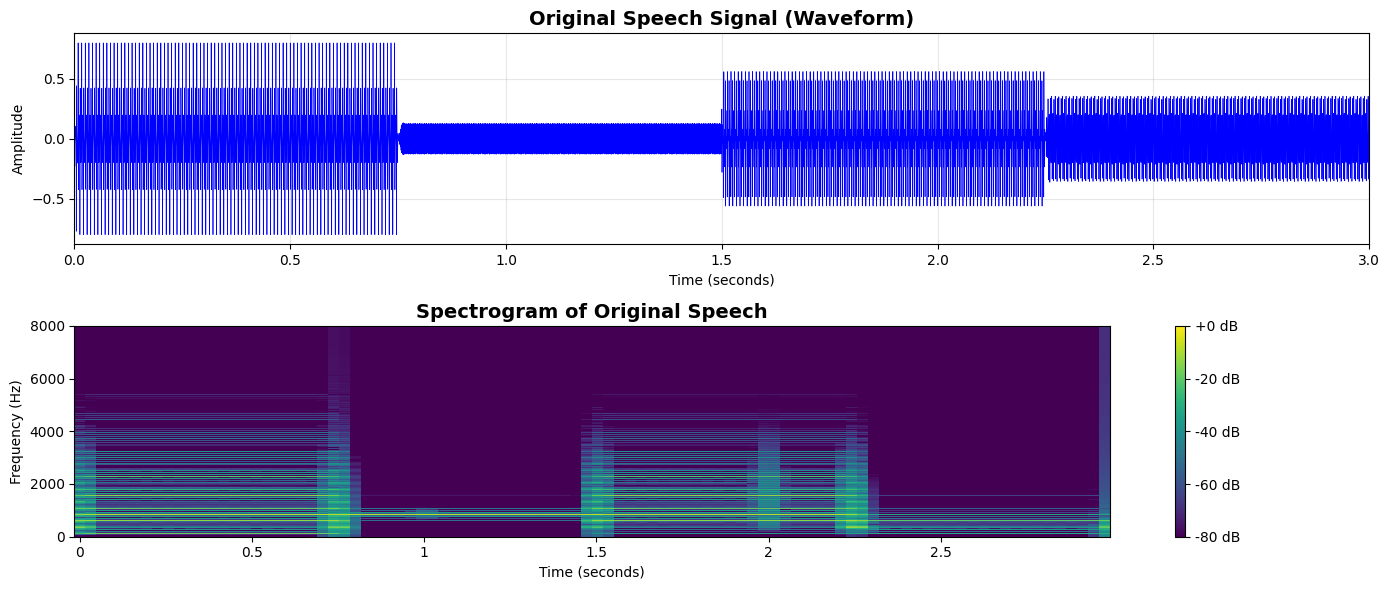


Original speech signal plotted successfully!


In [22]:
# ============================================================================
# SECTION 5: Plot Original Speech Signal
# ============================================================================

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
time_axis = np.linspace(0, len(speech_signal)/sample_rate, len(speech_signal))
plt.plot(time_axis, speech_signal, linewidth=0.5, color='blue')
plt.title('Original Speech Signal (Waveform)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.xlim([0, time_axis[-1]])

plt.subplot(2, 1, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(speech_signal)), ref=np.max)
librosa.display.specshow(D, sr=sample_rate, x_axis='time', y_axis='hz', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Original Speech', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

print("\nOriginal speech signal plotted successfully!")

In [23]:
# ============================================================================
# SECTION 6: LPC Analysis and Coefficient Extraction
# ============================================================================

def analyze_speech_lpc(signal_data, sr, frame_size=320, hop_size=160, lpc_order=12):
    """
    Analyze entire speech signal using LPC frame by frame
    """
    frames = []
    lpc_coefficients = []
    errors = []
    
    # Frame the signal
    for i in range(0, len(signal_data) - frame_size, hop_size):
        frame = signal_data[i:i + frame_size]
        frames.append(frame)
        
        # LPC analysis
        coeffs, error = lpc_analysis(frame, lpc_order)
        lpc_coefficients.append(coeffs)
        errors.append(error)
    
    return frames, lpc_coefficients, errors

print("\nPerforming LPC Analysis...")
lpc_order = 12
frame_size = 320  # 20ms at 16kHz
hop_size = 160    # 10ms at 16kHz

frames, lpc_coeffs_list, prediction_errors = analyze_speech_lpc(
    speech_signal, sample_rate, frame_size, hop_size, lpc_order
)

print(f"Total frames analyzed: {len(frames)}")
print(f"LPC order: {lpc_order}")
print(f"Frame size: {frame_size} samples ({frame_size/sample_rate*1000:.1f} ms)")
print(f"Hop size: {hop_size} samples ({hop_size/sample_rate*1000:.1f} ms)")

# Display sample LPC coefficients
print(f"\nSample LPC coefficients (Frame 50):")
print(lpc_coeffs_list[50])


Performing LPC Analysis...
Total frames analyzed: 298
LPC order: 12
Frame size: 320 samples (20.0 ms)
Hop size: 160 samples (10.0 ms)

Sample LPC coefficients (Frame 50):
[ 1.         -4.11237739  8.00683479 -9.52434897  7.21636251 -2.83933682
 -0.70528994  1.94154681 -1.36351891  0.3281361   0.23684461 -0.24635931
  0.08068335]


In [24]:
# ============================================================================
# SECTION 7: Speech Signal Reconstruction from LPC
# ============================================================================

def reconstruct_from_lpc(lpc_coeffs_list, original_signal, frame_size, hop_size):
    """
    Reconstruct speech signal from LPC coefficients
    """
    reconstructed = np.zeros(len(original_signal))
    window = hamming(frame_size)
    
    for idx, coeffs in enumerate(lpc_coeffs_list):
        start = idx * hop_size
        end = start + frame_size
        
        if end > len(reconstructed):
            break
        
        # Get original frame for excitation estimation
        original_frame = original_signal[start:end]
        
        # Inverse filter to get excitation (residual)
        excitation = lfilter(coeffs, 1, original_frame)
        
        # Synthesize using excitation
        synthesized_frame = lfilter(1, coeffs, excitation)
        
        # Apply window and overlap-add
        reconstructed[start:end] += synthesized_frame * window
    
    # Normalize
    reconstructed = reconstructed / np.max(np.abs(reconstructed)) * np.max(np.abs(original_signal))
    
    return reconstructed

print("\nReconstructing speech signal from LPC coefficients...")
reconstructed_signal = reconstruct_from_lpc(
    lpc_coeffs_list, speech_signal, frame_size, hop_size
)

print("Signal reconstruction complete!")

# Calculate reconstruction error
mse = np.mean((speech_signal[:len(reconstructed_signal)] - reconstructed_signal)**2)
snr = 10 * np.log10(np.var(speech_signal[:len(reconstructed_signal)]) / mse)
print(f"\nReconstruction Quality Metrics:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Signal-to-Noise Ratio: {snr:.2f} dB")


Reconstructing speech signal from LPC coefficients...
Signal reconstruction complete!

Reconstruction Quality Metrics:
Mean Squared Error: 0.000244
Signal-to-Noise Ratio: 22.12 dB


In [25]:
from IPython.display import Audio, display


print("Playing lpc reconstructed speech signal...")
audio_lpcreconst = Audio(data=reconstructed_signal, rate=sample_rate)
display(audio_lpcreconst)

Playing lpc reconstructed speech signal...


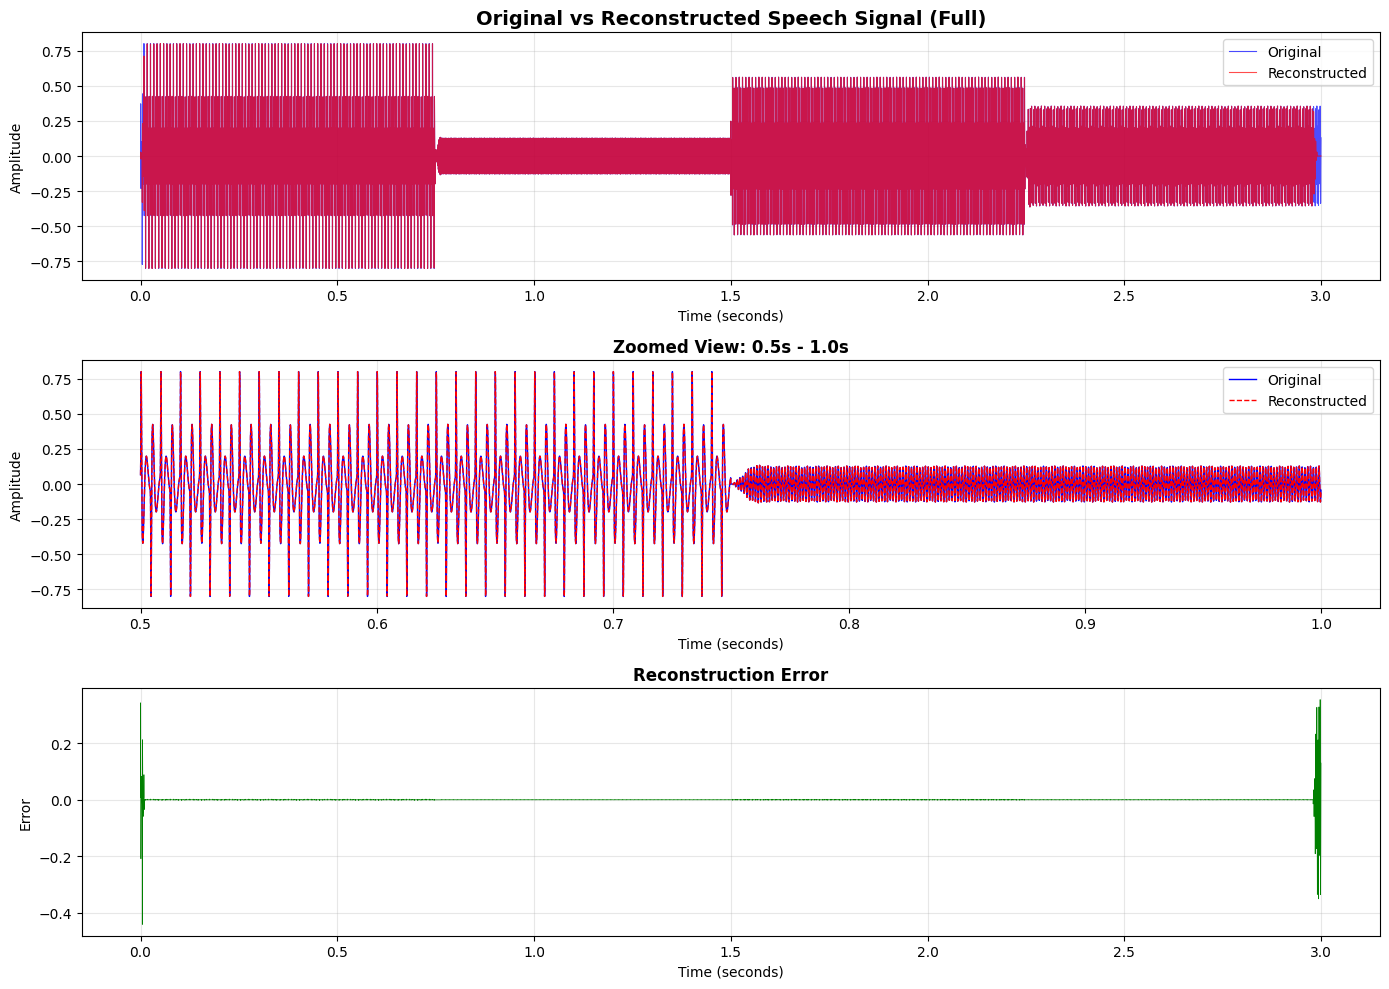


Original vs Reconstructed signals plotted successfully!


In [26]:
# ============================================================================
# SECTION 8: Plot Original vs Reconstructed Signals
# ============================================================================

plt.figure(figsize=(14, 10))

# Full signal comparison
plt.subplot(3, 1, 1)
time_axis = np.linspace(0, len(speech_signal)/sample_rate, len(speech_signal))
plt.plot(time_axis, speech_signal, label='Original', alpha=0.7, linewidth=0.8, color='blue')
recon_time = np.linspace(0, len(reconstructed_signal)/sample_rate, len(reconstructed_signal))
plt.plot(recon_time, reconstructed_signal, label='Reconstructed', alpha=0.7, linewidth=0.8, color='red')
plt.title('Original vs Reconstructed Speech Signal (Full)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoomed comparison (0.5s to 1.0s)
plt.subplot(3, 1, 2)
start_idx = int(0.5 * sample_rate)
end_idx = int(1.0 * sample_rate)
time_zoom = time_axis[start_idx:end_idx]
plt.plot(time_zoom, speech_signal[start_idx:end_idx], label='Original', linewidth=1, color='blue')
plt.plot(time_zoom, reconstructed_signal[start_idx:end_idx], label='Reconstructed', linewidth=1, color='red', linestyle='--')
plt.title('Zoomed View: 0.5s - 1.0s', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Error plot
plt.subplot(3, 1, 3)
error = speech_signal[:len(reconstructed_signal)] - reconstructed_signal
plt.plot(recon_time, error, color='green', linewidth=0.5)
plt.title('Reconstruction Error', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Error')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOriginal vs Reconstructed signals plotted successfully!")

In [27]:
# ============================================================================
# SECTION 9: Formant Frequency Estimation
# ============================================================================

def estimate_formants(lpc_coeffs, sr, num_formants=4):
    """
    Estimate formant frequencies from LPC coefficients
    """
    # Find roots of LPC polynomial
    roots = np.roots(lpc_coeffs)
    
    # Keep only roots inside unit circle
    roots = roots[np.abs(roots) < 1]
    
    # Convert to angles (frequencies)
    angles = np.arctan2(np.imag(roots), np.real(roots))
    
    # Convert to Hz
    freqs = angles * (sr / (2 * np.pi))
    
    # Keep only positive frequencies
    positive_mask = freqs > 0
    freqs = freqs[positive_mask]
    roots_filtered = roots[positive_mask]
    
    # Sort frequencies
    sort_idx = np.argsort(freqs)
    freqs = freqs[sort_idx]
    
    # Get bandwidths
    bandwidths = -0.5 * (sr / (2 * np.pi)) * np.log(np.abs(roots_filtered[sort_idx]))
    
    # Return first num_formants formants
    return freqs[:num_formants] if len(freqs) >= num_formants else freqs

print("\nEstimating formant frequencies...")

# Estimate formants for multiple frames
formant_data = []
frame_indices = [10, 30, 50, 70, 90]  # Sample frames

for frame_idx in frame_indices:
    if frame_idx < len(lpc_coeffs_list):
        formants = estimate_formants(lpc_coeffs_list[frame_idx], sample_rate, num_formants=4)
        formant_data.append({
            'frame': frame_idx,
            'time': frame_idx * hop_size / sample_rate,
            'formants': formants
        })
        print(f"\nFrame {frame_idx} (t={formant_data[-1]['time']:.2f}s):")
        for i, f in enumerate(formants[:2]):  # Show first 2 formants
            print(f"  F{i+1}: {f:.1f} Hz")


Estimating formant frequencies...

Frame 10 (t=0.10s):
  F1: 474.2 Hz
  F2: 1257.3 Hz

Frame 30 (t=0.30s):
  F1: 474.2 Hz
  F2: 1257.3 Hz

Frame 50 (t=0.50s):
  F1: 474.2 Hz
  F2: 1257.3 Hz

Frame 70 (t=0.70s):
  F1: 474.2 Hz
  F2: 1257.3 Hz

Frame 90 (t=0.90s):
  F1: 834.4 Hz
  F2: 903.3 Hz


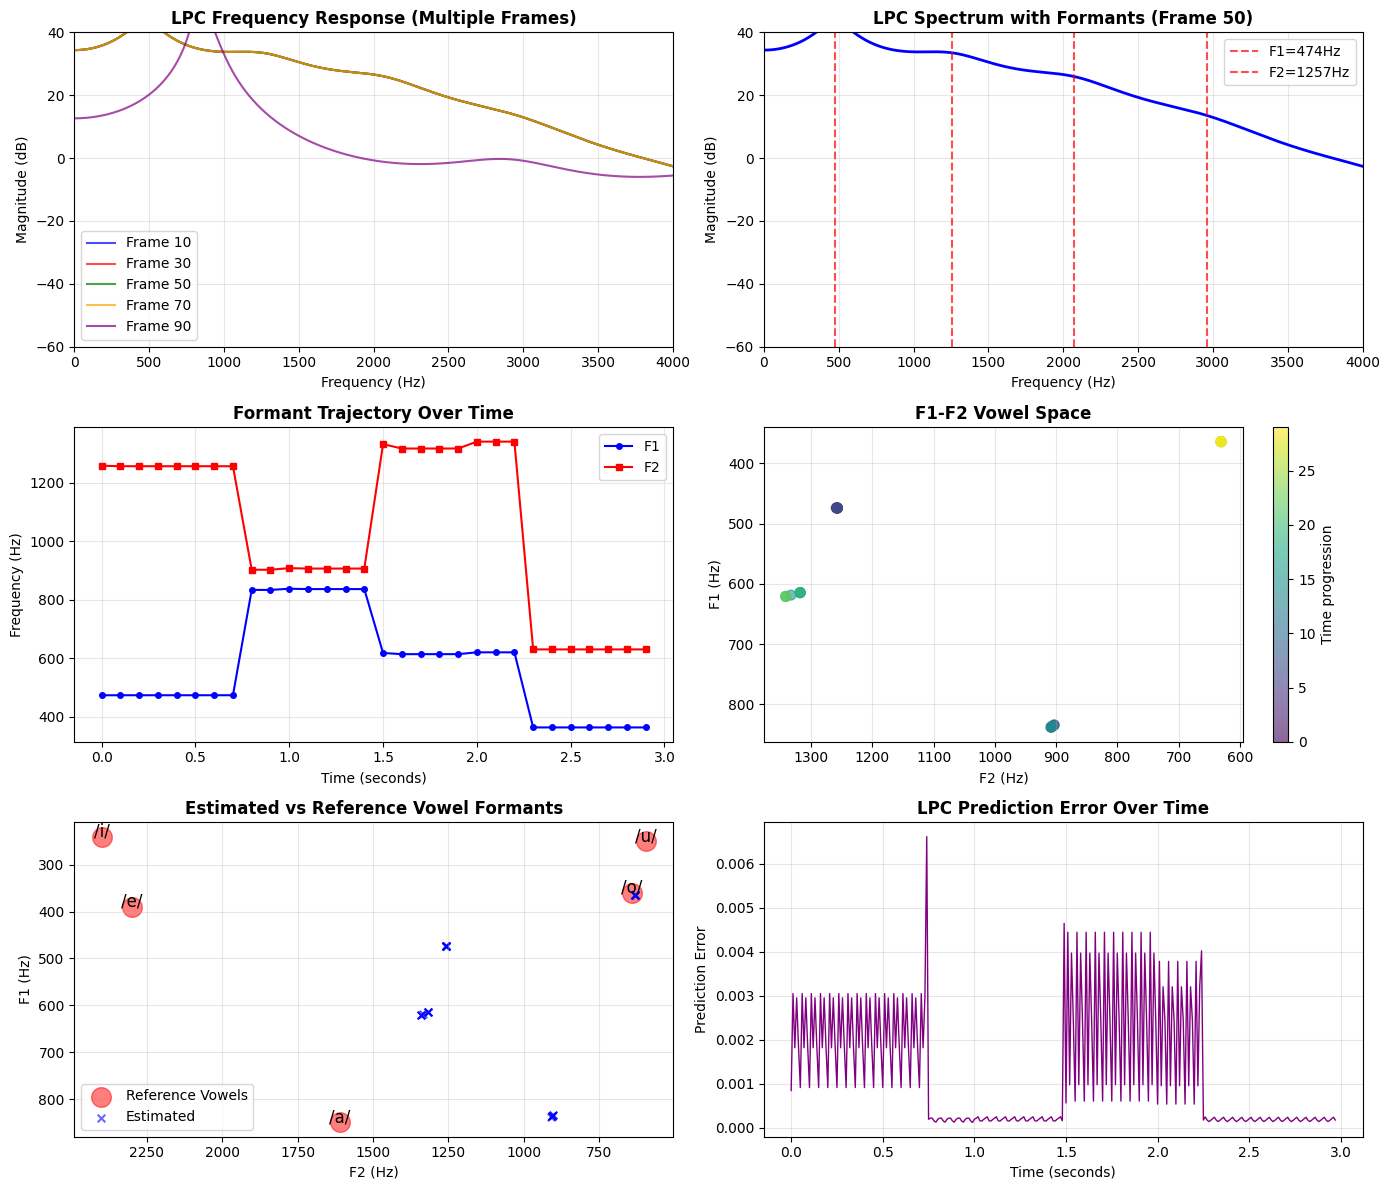


Formant visualization complete!


In [30]:
# ============================================================================
# SECTION 10: Frequency Response and Formant Visualization
# ============================================================================

def plot_lpc_spectrum(lpc_coeffs, sr, title="LPC Spectrum"):
    """
    Plot frequency response showing formant peaks
    """
    # Calculate frequency response
    w, h = signal.freqz(1, lpc_coeffs, worN=2048, fs=sr)
    h_db = 20 * np.log10(np.abs(h) + 1e-10)
    
    return w, h_db

# Plot formant analysis
plt.figure(figsize=(14, 12))

# Plot 1: LPC Spectrum for multiple frames
plt.subplot(3, 2, 1)
colors = ['blue', 'red', 'green', 'orange', 'purple']
for idx, frame_idx in enumerate(frame_indices):
    w, h_db = plot_lpc_spectrum(lpc_coeffs_list[frame_idx], sample_rate)
    plt.plot(w, h_db, label=f'Frame {frame_idx}', alpha=0.7, color=colors[idx])

plt.title('LPC Frequency Response (Multiple Frames)', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, 4000])
plt.ylim([-60, 40])
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Single frame with formant markers
plt.subplot(3, 2, 2)
frame_idx = 50
w, h_db = plot_lpc_spectrum(lpc_coeffs_list[frame_idx], sample_rate)
plt.plot(w, h_db, linewidth=2, color='blue')
formants = estimate_formants(lpc_coeffs_list[frame_idx], sample_rate, 4)
for i, f in enumerate(formants):
    plt.axvline(x=f, color='red', linestyle='--', alpha=0.7, label=f'F{i+1}={f:.0f}Hz' if i < 2 else '')
plt.title(f'LPC Spectrum with Formants (Frame {frame_idx})', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([0, 4000])
plt.ylim([-60, 40])
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 3: Formant trajectory over time (F1 and F2)
plt.subplot(3, 2, 3)
all_f1 = []
all_f2 = []
time_points = []

for idx in range(0, len(lpc_coeffs_list), 10):  # Every 10th frame
    formants = estimate_formants(lpc_coeffs_list[idx], sample_rate, 4)
    if len(formants) >= 2:
        all_f1.append(formants[0])
        all_f2.append(formants[1])
        time_points.append(idx * hop_size / sample_rate)

plt.plot(time_points, all_f1, 'o-', label='F1', color='blue', markersize=4)
plt.plot(time_points, all_f2, 's-', label='F2', color='red', markersize=4)
plt.title('Formant Trajectory Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: F1-F2 Vowel Space
plt.subplot(3, 2, 4)
plt.scatter(all_f2, all_f1, c=range(len(all_f1)), cmap='viridis', s=50, alpha=0.6)
plt.colorbar(label='Time progression')
plt.title('F1-F2 Vowel Space', fontsize=12, fontweight='bold')
plt.xlabel('F2 (Hz)')
plt.ylabel('F1 (Hz)')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# Plot 5: Formant comparison with reference vowels
plt.subplot(3, 2, 5)
vowel_names = ['i', 'a', 'e', 'u', 'o']
vowel_f1 = [vowel_formants[v]['F1'] for v in vowel_names if v in vowel_formants]
vowel_f2 = [vowel_formants[v]['F2'] for v in vowel_names if v in vowel_formants]

plt.scatter(vowel_f2, vowel_f1, s=200, marker='o', c='red', alpha=0.5, label='Reference Vowels')
for i, v in enumerate(vowel_names):
    if v in vowel_formants:
        plt.annotate(f'/{v}/', (vowel_f2[i], vowel_f1[i]), fontsize=12, ha='center')

plt.scatter(all_f2, all_f1, s=30, marker='x', c='blue', alpha=0.6, label='Estimated')
plt.title('Estimated vs Reference Vowel Formants', fontsize=12, fontweight='bold')
plt.xlabel('F2 (Hz)')
plt.ylabel('F1 (Hz)')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Prediction Error over time
plt.subplot(3, 2, 6)
error_time = np.arange(len(prediction_errors)) * hop_size / sample_rate
plt.plot(error_time, prediction_errors, linewidth=1, color='purple')
plt.title('LPC Prediction Error Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Prediction Error')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFormant visualization complete!")

In [31]:
# ============================================================================
# SECTION 11: Comparison Table - Expected vs Estimated Formants
# ============================================================================

print("\n" + "="*80)
print("FORMANT COMPARISON TABLE: Expected vs Estimated")
print("="*80)

# Calculate average formants from our signal
avg_f1 = np.mean(all_f1) if all_f1 else 0
avg_f2 = np.mean(all_f2) if all_f2 else 0

print(f"\nEstimated Average Formants from Signal:")
print(f"  F1: {avg_f1:.1f} Hz")
print(f"  F2: {avg_f2:.1f} Hz")

print(f"\nComparison with Reference Vowels:")
print(f"{'Vowel':<8} {'Ref F1 (Hz)':<15} {'Ref F2 (Hz)':<15} {'Est F1':<15} {'Est F2':<15} {'Match':<10}")
print("-" * 80)

# Find closest vowel match
min_distance = float('inf')
closest_vowel = None

for vowel, data in vowel_formants.items():
    if vowel in ['i', 'a', 'e', 'u', 'o']:  # Common vowels
        ref_f1 = data['F1']
        ref_f2 = data['F2']
        
        # Calculate Euclidean distance
        distance = np.sqrt((avg_f1 - ref_f1)**2 + (avg_f2 - ref_f2)**2)
        
        match_indicator = "✓" if distance < 500 else ""
        
        print(f"{vowel:<8} {ref_f1:<15} {ref_f2:<15} {avg_f1:<15.1f} {avg_f2:<15.1f} {match_indicator:<10}")
        
        if distance < min_distance:
            min_distance = distance
            closest_vowel = vowel

print("-" * 80)
print(f"\nClosest vowel match: /{closest_vowel}/ (Distance: {min_distance:.1f} Hz)")


FORMANT COMPARISON TABLE: Expected vs Estimated

Estimated Average Formants from Signal:
  F1: 571.3 Hz
  F2: 1048.3 Hz

Comparison with Reference Vowels:
Vowel    Ref F1 (Hz)     Ref F2 (Hz)     Est F1          Est F2          Match     
--------------------------------------------------------------------------------
i        240             2400            571.3           1048.3                    
e        390             2300            571.3           1048.3                    
a        850             1610            571.3           1048.3                    
o        360             640             571.3           1048.3          ✓         
u        250             595             571.3           1048.3                    
--------------------------------------------------------------------------------

Closest vowel match: /o/ (Distance: 459.8 Hz)
